In [3]:
import zipfile

zip_path = r"C:/Users/hi/Downloads/archive.zip"
extract_to = r"C:/Users/hi/Downloads/archive_extracted"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print("✅ Extraction complete!")


✅ Extraction complete!


In [4]:
import os
import shutil
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt  # correct import
import cv2
import skimage
import skimage.segmentation as seg  # use a different alias
import random

%matplotlib inline

plt.style.use('ggplot')  # now it works



In [5]:
import os
import cv2
import numpy as np

labels = ['PNEUMONIA', 'NORMAL']
img_size = 128

def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                # ✅ Only read image files
                if not img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # ✅ Skip if OpenCV fails to read
                if img_arr is None:
                    continue

                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])

            except Exception as e:
                print(f"Error loading image {img}: {e}")
    
    return np.array(data, dtype=object)


In [6]:
train = get_data("chest_xray/chest_xray/train")
test = get_data("chest_xray/chest_xray/test")
val = get_data("chest_xray/chest_xray/val")

In [7]:
pneumonia = os.listdir("chest_xray/train/PNEUMONIA")
penomina_dir = "chest_xray/train/PNEUMONIA"

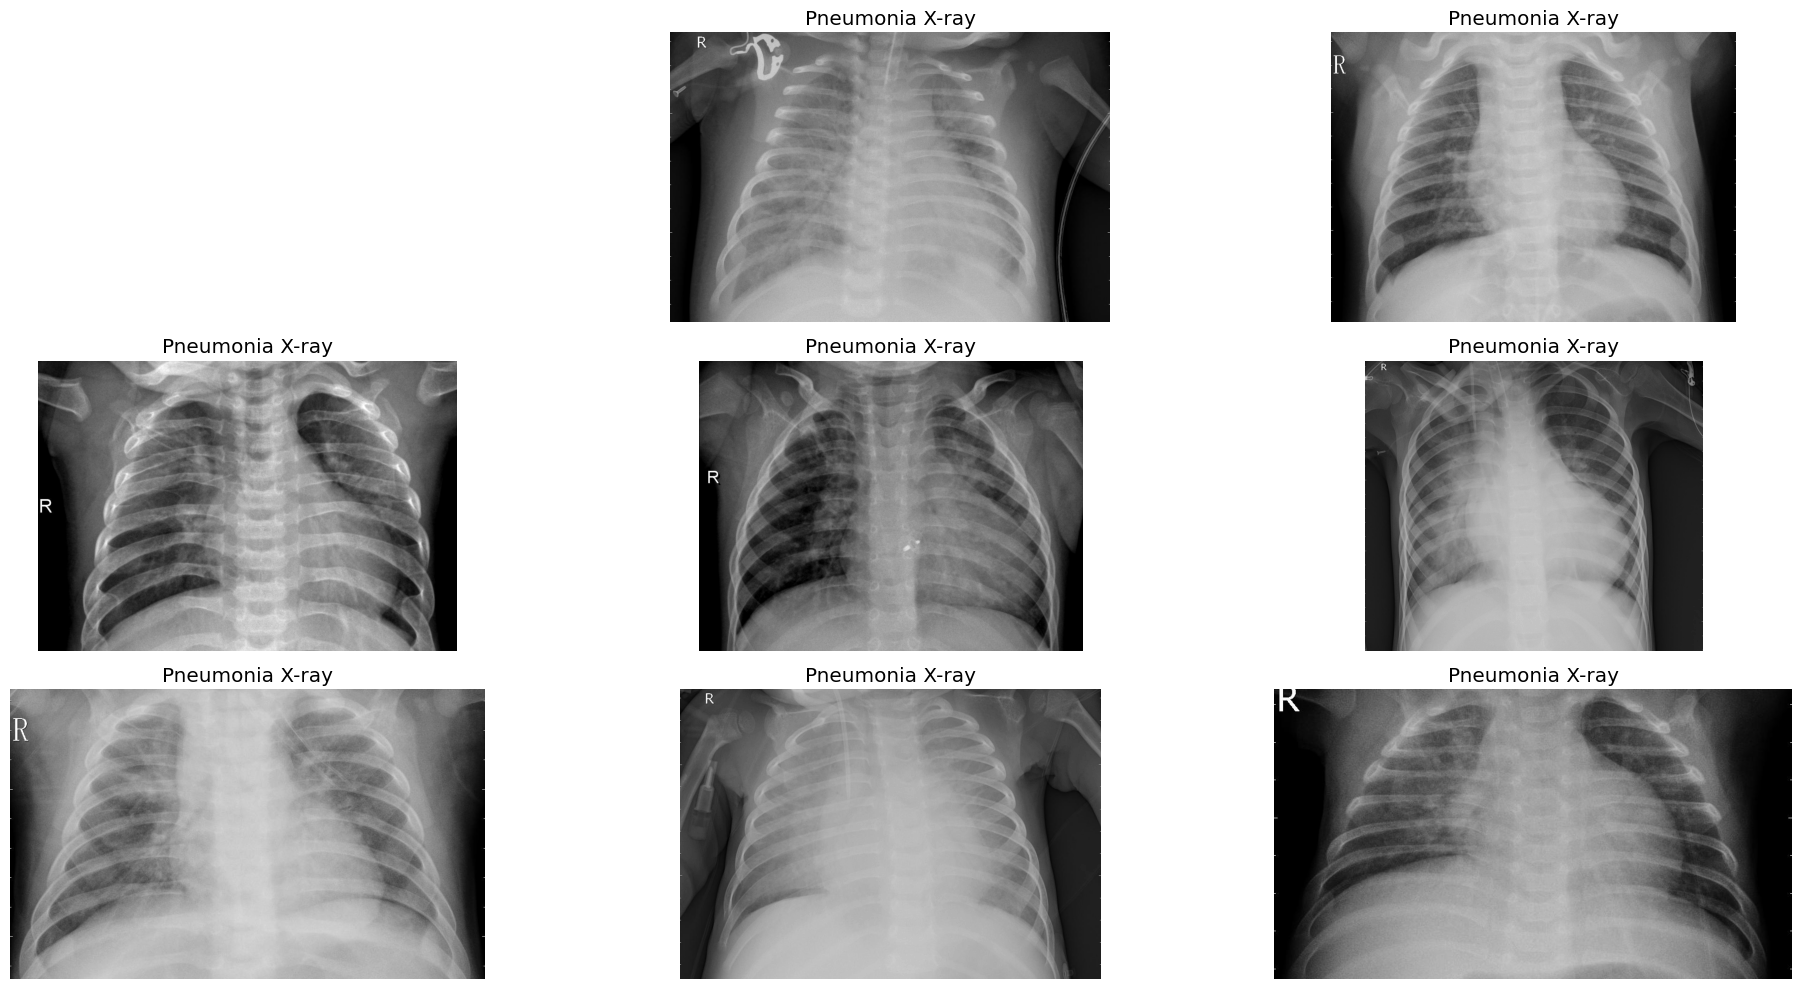

In [8]:
import os
import matplotlib.pyplot as plt

penomina_dir = "chest_xray/chest_xray/train/PNEUMONIA"
pneumonia = os.listdir(penomina_dir)

plt.figure(figsize=(20,10))

for i in range(9):
    img_path = os.path.join(penomina_dir, pneumonia[i])

    # ✅ Skip non-image files
    if not (img_path.endswith('.jpg') or img_path.endswith('.png') or img_path.endswith('.jpeg')):
        continue

    img = plt.imread(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis("off")
    plt.title("Pneumonia X-ray")

plt.tight_layout()
plt.show()


In [9]:
normal = os.listdir("chest_xray/train/NORMAL")
normal_dir = "chest_xray/train/NORMAL"

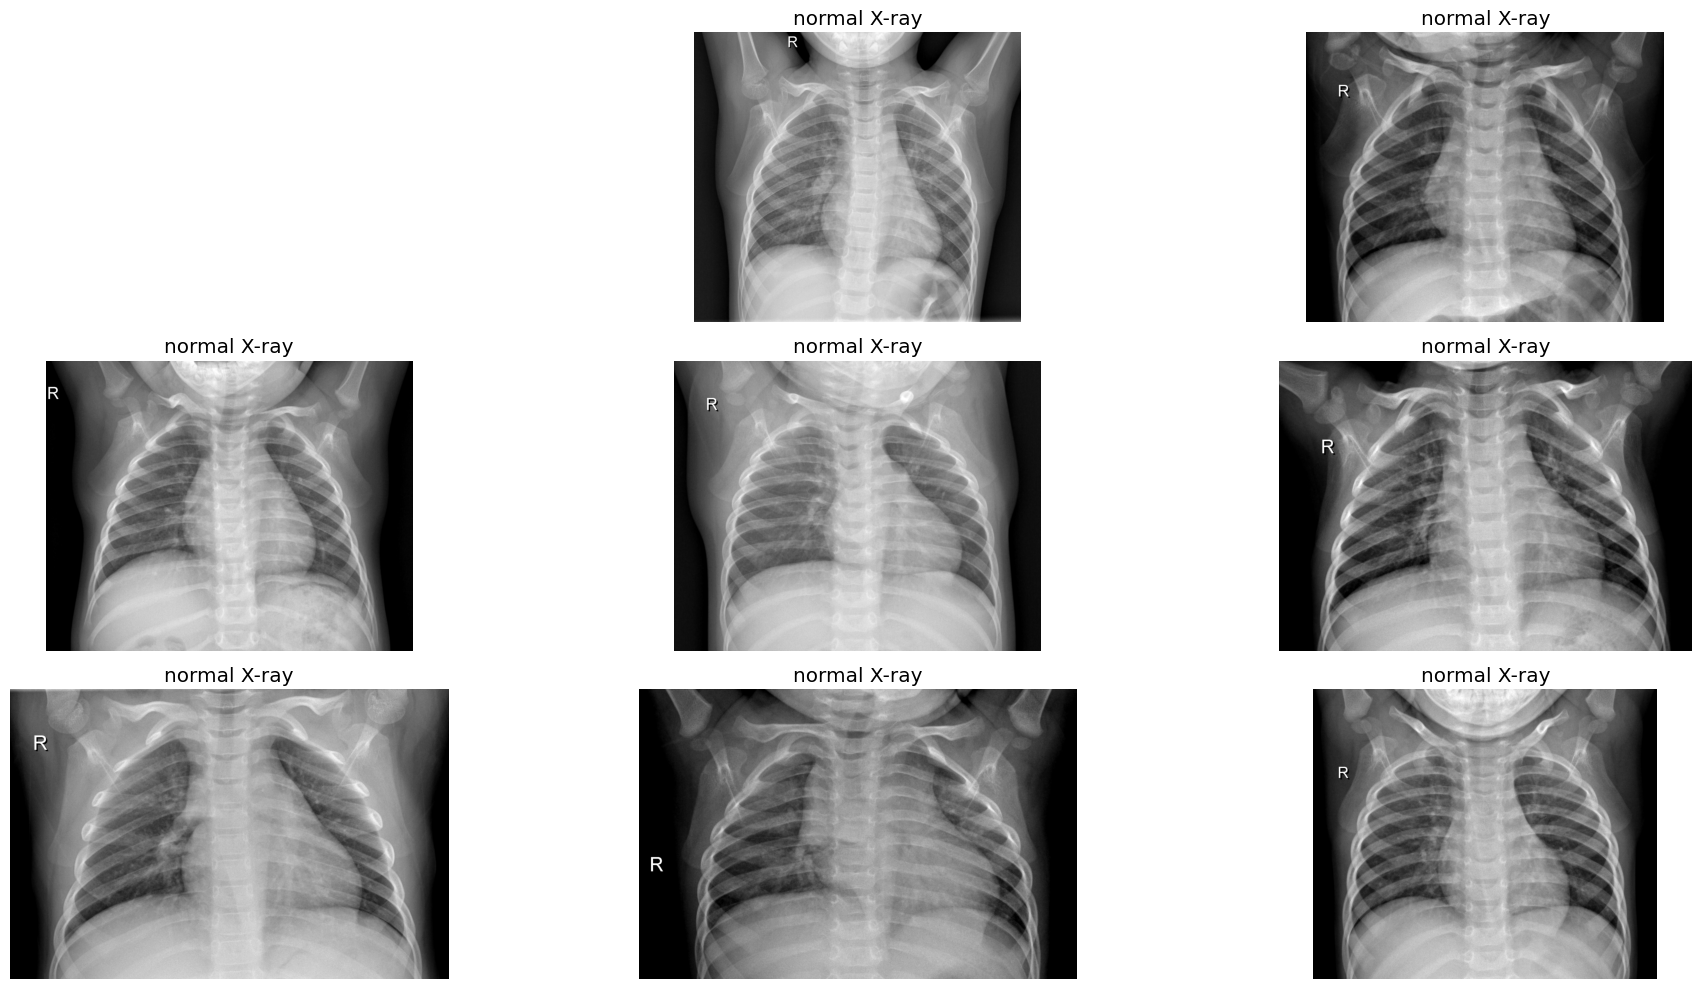

In [10]:
import os
import matplotlib.pyplot as plt

normal_dir = "chest_xray/chest_xray/train/NORMAL"
normal = os.listdir(normal_dir)

plt.figure(figsize=(20,10))

for i in range(9):
    img_path = os.path.join(normal_dir, normal[i])

    # ✅ Skip non-image files
    if not (img_path.endswith('.jpg') or img_path.endswith('.png') or img_path.endswith('.jpeg')):
        continue

    img = plt.imread(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis("off")
    plt.title("normal X-ray")

plt.tight_layout()
plt.show()


C:\Users\hi\Desktop\jupyter\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


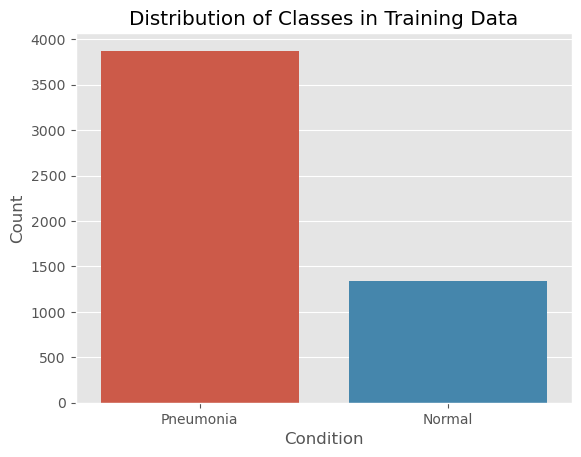

In [11]:
import seaborn as sns  # you forgot to import seaborn
import matplotlib.pyplot as plt

listx = []

for i in train:
    if i[1] == 0:   # ✅ fix: [i] == 0 was wrong
        listx.append("Pneumonia")
    else:
        listx.append("Normal")

sns.countplot(x=listx)
plt.title("Distribution of Classes in Training Data")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()


In [12]:
# Data Augmentation & Resizing

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Flatten, MaxPooling2D, Conv2D, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=40,
    shear_range=0.2,
    width_shift_range=0.4,
    height_shift_range=0.4,
    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [15]:
train_generator = train_datagen.flow_from_directory(
    "chest_xray/chest_xray/train",
    batch_size=32,
    target_size=(128, 128),
    class_mode='categorical',
    shuffle=True,
    seed=42,
    color_mode='rgb'
)

valid_generator = valid_datagen.flow_from_directory(
    "chest_xray/chest_xray/val",
    batch_size=32,
    target_size=(128, 128),
    class_mode='categorical',
    shuffle=True,
    seed=42,
    color_mode='rgb'
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [16]:
class_labels = train_generator.class_indices

In [17]:
class_labels

{'NORMAL': 0, 'PNEUMONIA': 1}

In [18]:
class_name = {value:key for (key,value)in class_labels.items()}

In [19]:
class_name

{0: 'NORMAL', 1: 'PNEUMONIA'}

In [20]:
#Vgg19 Cnn Architecture

In [21]:
base_model = VGG19(input_shape = (128,128,3),
                     include_top = False,
                     weights = 'imagenet')
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
flat = Flatten()(x)


class_1 = Dense(4608, activation = 'relu')(flat)
dropout = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation = 'relu')(dropout)
output = Dense(2, activation = 'softmax')(class_2)

model_01 = Model(base_model.inputs, output)
model_01.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0     

In [22]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

filepath = "model.h5"
es = EarlyStopping(monitor="val_loss", verbose=1, mode="min", patience=4)
cp = ModelCheckpoint(filepath, monitor="val_loss", save_best_only=True, mode="auto", save_freq="epoch")
lrr = ReduceLROnPlateau(monitor="val_accuracy", patience=3, verbose=1, factor=0.5, min_lr=0.0001)

# ✅ Remove `decay`
sgd = SGD(learning_rate=0.0001, momentum=0.0, nesterov=True)

model_01.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=['accuracy'])


In [23]:
history_01 = model_01.fit(train_generator, 
            steps_per_epoch=50,
            epochs=1, 
            callbacks=[es, cp, lrr],
            validation_data=valid_generator)

50/50 [==============================] - 258s 5s/step - loss: 0.5710 - accuracy: 0.7462 - val_loss: 0.9533 - val_accuracy: 0.5000 - lr: 1.0000e-04


In [24]:
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")
model_01.save(filepath = "model_weights/vgg19_model_01.h5", overwrite=True)


In [25]:
test_generator = test_datagen.flow_from_directory("chest_xray/chest_xray/test",
                                 batch_size = 32,
                                 target_size=(128,128),
                                 class_mode = 'categorical',
                                 shuffle=True,
                                 seed = 42,
                                 color_mode = 'rgb')

Found 624 images belonging to 2 classes.


In [26]:
model_01.load_weights("model_weights/vgg19_model_01.h5")

vgg_val_eval_01 = model_01.evaluate(valid_generator)
vgg_test_eval_01 = model_01.evaluate(test_generator)

20/20 [==============================] - 70s 3s/step - loss: 0.7367 - accuracy: 0.6250


In [27]:
print(f"Validation Loss: {vgg_val_eval_01[0]}")
print(f"Validation Accuarcy: {vgg_val_eval_01[1]}")
print(f"Test Loss: {vgg_test_eval_01[0]}")
print(f"Test Accuarcy: {vgg_test_eval_01[1]}")

Validation Loss: 0.9532651901245117
Validation Accuarcy: 0.5
Test Loss: 0.7367007732391357
Test Accuarcy: 0.625


In [28]:
base_model = VGG19(include_top=False, input_shape=(128,128,3))
base_model_layer_names = [layer.name for layer in base_model.layers]

x = base_model.output
flat = Flatten()(x)


class_1 = Dense(4608, activation = 'relu')(flat)
dropout = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation = 'relu')(dropout)
output = Dense(2, activation = 'softmax')(class_2)

model_02 = Model(base_model.inputs, output)
model_02.load_weights("model_weights/vgg19_model_01.h5")

set_trainable = False
for layer in base_model.layers:
    if layer.name in [ 'block5_conv3','block5_conv4']:
        set_trainable=True
    if set_trainable:
        set_trainable=True
    else:
        set_trainable=False
print(model_02.summary())

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

In [29]:
base_model_layer_names

['input_2',
 'block1_conv1',
 'block1_conv2',
 'block1_pool',
 'block2_conv1',
 'block2_conv2',
 'block2_pool',
 'block3_conv1',
 'block3_conv2',
 'block3_conv3',
 'block3_conv4',
 'block3_pool',
 'block4_conv1',
 'block4_conv2',
 'block4_conv3',
 'block4_conv4',
 'block4_pool',
 'block5_conv1',
 'block5_conv2',
 'block5_conv3',
 'block5_conv4',
 'block5_pool']

In [30]:
from tensorflow.keras.optimizers import SGD

sgd = SGD(learning_rate=0.0001, momentum=0.0, nesterov=True)

model_02.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=['accuracy'])


In [31]:
history_02 = model_02.fit(train_generator, 
            steps_per_epoch=10,
            epochs=1, 
            callbacks=[es, cp, lrr],
            validation_data=valid_generator)

10/10 [==============================] - 146s 14s/step - loss: 0.5207 - accuracy: 0.7906 - val_loss: 0.9762 - val_accuracy: 0.5000 - lr: 1.0000e-04


In [32]:
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")
model_02.save(filepath = "model_weights/vgg19_model_02.h5", overwrite=True)
model_02.load_weights("model_weights/vgg19_model_02.h5")

vgg_val_eval_02 = model_02.evaluate(valid_generator)
vgg_test_eval_02 = model_02.evaluate(test_generator)

print(f"Validation Loss: {vgg_val_eval_02[0]}")
print(f"Validation Accuarcy: {vgg_val_eval_02[1]}")
print(f"Test Loss: {vgg_test_eval_02[0]}")
print(f"Test Accuarcy: {vgg_test_eval_02[1]}")

20/20 [==============================] - 67s 3s/step - loss: 0.7495 - accuracy: 0.6250
Validation Loss: 0.9761683344841003
Validation Accuarcy: 0.5
Test Loss: 0.7495449781417847
Test Accuarcy: 0.625
